# Basics of PyTorch - Model Optimization
### Date: 02/22/2025
### by Malik N. Mohammed

## Objectives
- Training a model
- Calculate the error/loss and get the derivate of it's error w.r.t parameters.
- Optimize the parameters using gradient descent.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
# Get the accelerator.
device = 'cpu'

if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()

device

device(type='cuda')

In [3]:
# Get the training dataset.
training_data = datasets.MNIST(
    'data',
    download=True,
    train=True,
    transform=ToTensor()
)

# Get the test dataset.
test_data = datasets.MNIST(
    'data',
    download=True,
    train=False,
    transform=ToTensor()
)

In [4]:
batch_size = 64

# Get the training and test data loader with a batch size of 64
train_loader = DataLoader(training_data, batch_size=batch_size)
test_loader = DataLoader(test_data, batch_size=batch_size)

In [5]:
train_loader

In [6]:
# Build the model.

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            # nn.ReLU(),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 512),
            # nn.ReLU(),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)

        return logits

In [7]:
# Instantiate the model.
model = NeuralNetwork().to(device)
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)

### Implementing the training and test loop.

In this section we define the training and testing loop helper methods that takes care of:
- Setting the model in training mode.
- Computing the loss
- Performing the gradient calculation and resetting the gradient before moving to the next batch.
- Setting the model in evaluation mode.
- Computing the loss and correct predictions to compute accuracy.

In [8]:
def train_loop(dataloader, model, loss_fn, optimizer):
    """
    Initiates the training loop.
    """

    size = len(dataloader.dataset)

    # Set the model for training.
    model.train()

    for batch, (X, y) in enumerate(dataloader):

        # Move the data to the device.
        X, y = X.to(device), y.to(device)

        # Get the models's predictions as logits.
        pred = model(X)

        # Get the loss between the predicted and actual label.
        loss = loss_fn(pred, y)

        # Computer the gradient of loss w.r.t the model's parameters.
        loss.backward()

        # Perform the model parameter update (uses the learning rate).
        optimizer.step()

        # Reset the model's gradients.
        optimizer.zero_grad()

        # Print the loss and current sample info.
        if batch % 200 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{current: >5d}/{size:>5d}]")

In [9]:
def test_loop(dataloader, model, loss_fn):
    """
    Initiates the test loop.

    Returns: average loss and accuracy.
    """
    
    # Set the model in the evaluation mode.
    model.eval()

    total_loss, correct = 0, 0
    num_batches = len(dataloader)
    size = len(dataloader.dataset)
    
    for X, y in dataloader:

        # Move the samples, and labels to device.
        X, y = X.to(device), y.to(device)

        # Disable the gradient tracking.
        with torch.no_grad():
            pred = model(X)

            # Get the loss.
            loss = loss_fn(pred, y)

            # Add the loss to the total loss.
            total_loss += loss.item()

            # Get the number of correct predictions in the current batch.
            correct += (pred.argmax(dim=1) == y).type(torch.float).sum().item()


    avg_loss = total_loss / num_batches
    accuracy = correct / size
    print(f"Total loss: {avg_loss:>6f}, Accuracy: {100*accuracy:>0.1f}%")
    print("---\n")

    return avg_loss, accuracy

        

### Hyperparameters
Hyperparameters are adjustable parameters that helps us to control the models optimization process.

We use the following hyperparameters in this notebook:
- *Epochs* - number of times to iterate over the dataset.
- *Batch Size* - number of samples propagated through the neural network before the parameter update is performed.
- *Learning Rate ($\alpha$)* - how much to update models parameters at each batch/epoch.
   - Smaller the value slower the learning.

In [10]:
# Define the hyperparameters.
epochs = 10
batch_size = 64
learning_rate = 1e-3
# learning_rate = 1e-2

In [11]:
# Get the loss function.
loss_fn = nn.CrossEntropyLoss()

# Initialize the optimizer with learning rate and current model parameters.
optimizers = [
    torch.optim.SGD(model.parameters(), lr=learning_rate),
    torch.optim.Adam(model.parameters(), lr=learning_rate)
]

In [12]:
# Get the learning rate from the optimizer.
optimizers[0].param_groups[0]['lr']

0.001

In [13]:
patience = 5

for optimizer in optimizers:
    best_test_loss = float('inf')

    print(f"Using '{type(optimizer).__name__}' optimizer with a learning rate of {optimizer.param_groups[0]['lr']:>.3f}")
    no_improvement_count = 0
    for epoch in range(epochs):
        print(f"Epoch: {epoch}")
        train_loop(train_loader, model, loss_fn, optimizer)
        loss, _ = test_loop(test_loader, model, loss_fn)
    
        if loss < best_test_loss:
            best_test_loss = loss
            no_improvement_count = 0
        else:
            no_improvement_count += 1
    
        if no_improvement_count >= patience:
            print(f"Early stopping because the model didn't improve after {no_improvement_count} epochs")
            break

    print("\n=================================\n\n")

print("Done")

Using 'SGD' optimizer with a learning rate of 0.001
Epoch: 0
loss: 2.296790 [   64/60000]
loss: 2.292726 [12864/60000]
loss: 2.282126 [25664/60000]
loss: 2.280979 [38464/60000]
loss: 2.262496 [51264/60000]
Total loss: 2.258008, Accuracy: 39.7%
---

Epoch: 1
loss: 2.252177 [   64/60000]
loss: 2.253170 [12864/60000]
loss: 2.233618 [25664/60000]
loss: 2.221311 [38464/60000]
loss: 2.207560 [51264/60000]
Total loss: 2.195458, Accuracy: 61.6%
---

Epoch: 2
loss: 2.192273 [   64/60000]
loss: 2.201761 [12864/60000]
loss: 2.169012 [25664/60000]
loss: 2.129533 [38464/60000]
loss: 2.110519 [51264/60000]
Total loss: 2.090548, Accuracy: 64.0%
---

Epoch: 3
loss: 2.095586 [   64/60000]
loss: 2.105174 [12864/60000]
loss: 2.046615 [25664/60000]
loss: 1.986529 [38464/60000]
loss: 1.944791 [51264/60000]
Total loss: 1.909366, Accuracy: 65.0%
---

Epoch: 4
loss: 1.913796 [   64/60000]
loss: 1.935199 [12864/60000]
loss: 1.849611 [25664/60000]
loss: 1.733286 [38464/60000]
loss: 1.718406 [51264/60000]
Total 

In [14]:
# Get the batch of images and labels.
images, labels = next(iter(test_loader))

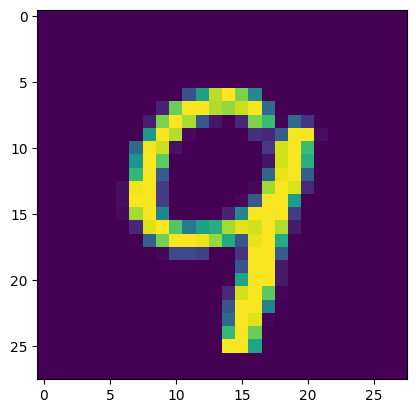

Predicted Logits:  tensor([[ -8.1116, -15.7825, -10.0014,  -4.8836,  -0.8230,  -8.1125, -20.8873,
          -0.6329,  -4.0193,  16.9096]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

Prediction: tensor([9], device='cuda:0')
Actual: 9


In [15]:
# Get random index between the batch size.
idx = torch.randint(0, batch_size, size=(1,)).item()

# Print the random number image from the MNIST dataset.
plt.imshow(images[idx].reshape(28, -1))
plt.show()

# Get the predicted logits.
logits = model(images[idx].to(device))


print('Predicted Logits: ', logits)

# Perform the softmax and get the highest probability index.
# Note: this prediction is based on the training done using Adam optimizer.
prediction = nn.functional.softmax(logits, dim=1).argmax(dim=1)
print(f"\nPrediction: {prediction}")
print(f"Actual: {labels[idx]}")